## importo pandas y cargo el archivo .csv

In [1]:
import pandas as pd

In [2]:
tabla = pd.read_csv (r'C:\Users\emilio\Downloads\netflix_titles.csv\netflix_titles.csv')
tabla.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1- ¿Cuántos títulos hay en el catálogo de Netflix?

In [3]:
titulos_totales = tabla.shape[0]
titulos_totales

8807

Nos indica que hay 8807 Títulos en el catálogo de Netflix

## 2- ¿Cuántas películas y cuántas series hay?

<Axes: ylabel='type'>

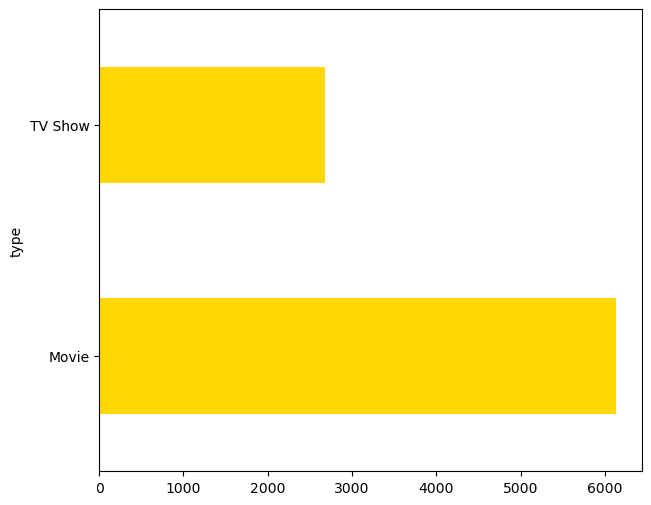

In [4]:
tabla.type.value_counts().plot(kind='barh', color='gold',figsize=(7,6))

Hay un total de 6.131 películas y 
un total de 2.676 series


## 3- ¿Cuántos titulos distintos hay por tipo y por año?

In [5]:
titulos_distintos = tabla.groupby(['type', 'release_year'])['title'].count()
tabla_comparativa = titulos_distintos.unstack()
tabla_comparativa.fillna(0).tail(10)

release_year,1925,1942,1943,1944,1945,1946,1947,1954,1955,1956,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
type,,,,,,,,,,,,,,,,,,,,,
Movie,0.0,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,2.0,...,173.0,225.0,264.0,398.0,658.0,767.0,767.0,633.0,517.0,277.0
TV Show,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,64.0,63.0,88.0,162.0,244.0,265.0,380.0,397.0,436.0,315.0


Aqui tenemos los titulos que hay diferentes por cada año, tanto de series como de peliculas

## 4- ¿Qué columnas tienen valores nulos y cuántos?

In [6]:
tabla.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Podemos observar que en las columnas(show_id, type, title, release_year, listed_in y description) hay 0 nulos, mientras que en las columnas ( director, cast, country, date_added, rating y duration) aunque las 2 ultimas no sean de mucha importacia dado a que tienen 3 y 4 valores nulos, los demas tienen bastantes, sobre todo la columna director.

## 5- ¿Qué porcentaje del catálogo tiene información del director?

In [7]:
directores = tabla['director'].count()

In [8]:
titulos_totales = tabla.shape[0]

In [9]:
porcentaje = (directores / titulos_totales)*100
print(porcentaje)

70.09197229476553


Nos indica que el 70.09% del catálogo de Netflix tiene Director conocido

## 6- ¿Cuáles son los países con mas títulos en Netflix?

In [10]:
paises = tabla['country'].dropna().str.split(",").explode().str.strip()

In [11]:
top_ciudades = paises.value_counts()
top_ciudades = top_ciudades.head(10)
top_ciudades

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

Para poder llegar a este resultado le digo que "paises" es igual a "country" pero eliminando los "Na".

Separo las palabras cuando encuentre "," para tener las palabras sueltas.

Por ultimo le digo que elimine los espacios que puedan haber para que asi no me de fallo cuando los cuente.

El resultado es que United States es el pais con mas titulos en Netflix, mientras que Mexico es el que menos tiene.

## 7- ¿Qué géneros son los más frecuentes en el catálogo?

In [12]:
generos = tabla['listed_in'].dropna().str.split(",").explode().str.strip()

In [13]:
top_generos = generos.value_counts().head(10)

In [14]:
top_generos

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Para llegar a la siguiente conclusión he tenido que usar el comando "dropna" para eliminar las celdas sin datos.

Después el comando "str.split(",")"  para asi que pandas separe las palabras cuando detecte ",".

Por ultimo "str.strip()" para eliminar los espacios en blanco.

Se puede apreciar como el género más frecuente en el catálogo de Netflix es "International Movies" seguido de "Dramas", y los menos frecuentes son " Romantic Movies".

## 8- ¿Cuál es la duración media de las películas? 

In [15]:
peliculas = tabla[tabla['type'] == 'Movie'].copy()
peliculas['duration'] = peliculas['duration'].str.replace(' min', '')
peliculas['duration'] = peliculas['duration'].astype(float)

In [16]:
media = peliculas['duration'].mean()
print(media)

99.57718668407311


Creo un DataFrame y le pongo "copy" para que los datos se queden en una columna virtual y pandas no intente cambiar la tabla original.

Después hago que busque la palabra " min" y la remplaza por nada para evitar errores.

Por último transformo el tipo de dato de la columna de texto a número con decimales.

La conclusión final es que la duración media de las peliculas es de 99.58 horas exactamente.

## 9- ¿En qué años se añadieron más títulos a Netflix?

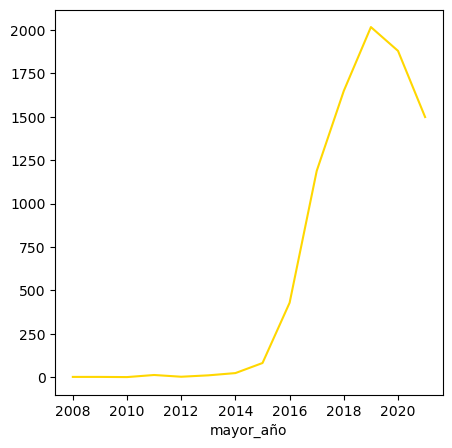

In [19]:
tabla['date_added'] = tabla['date_added'].str.strip()
tabla['date_added'] = pd.to_datetime(tabla['date_added'])
tabla['mayor_año'] = tabla['date_added'].dt.year
tabla['mayor_año'].value_counts().sort_index().plot(kind='line', color='gold', figsize=(5,5));

Primero uso el comando "str.strip()" para eliminar los espacios en blanco

Uso el comando "pd.to_datetime" para convertir el texto en fecha real, en la siguiente linea creo una nueva columna que contenga solo el año de la columna original de fecha, despues hago que cuente las veces que aparece cada año, el comando "sort_index" los ordena de forma ascendente para que el gráfico final tenga sentido.

He añadido al final de la linea un ";" para que jupyter notebook no muestre el texto técnico

Se puede apreciar qué el año en el qué más títulos es añadieron fue el 2020, seguido del 2018

## 10- ¿Ha aumentado la producción de series los últimos años?

In [28]:
tabla['year_added'] = pd.to_datetime(tabla['date_added'].astype(str).str.strip()).dt.year
series = tabla[tabla['type']  == 'TV Show']
conteo = series['year_added'].value_counts().sort_index()

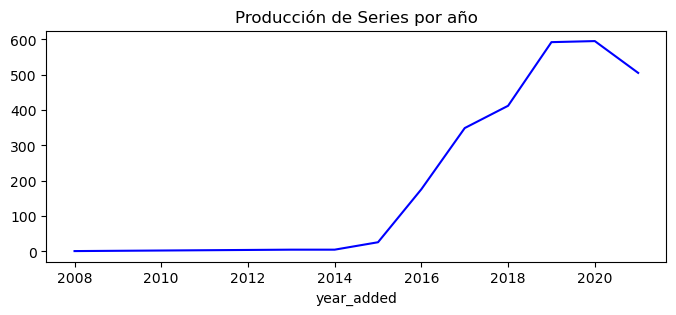

In [43]:
conteo.plot(kind='line', color='blue', title='Producción de Series por año', figsize=(8,3));

Para empezar pongo el codigo "pd.to_datetime" para que la columna que especifico entienda que son fechas.

Seguido el comando "astype(str)" indica que todos los datos son strings.

El comando "str.strip()" para limpiar los espacios.

Y "dt.year" para que coja solo el año de cada fecha

Después hago una sub-tabla que contiene solo las series.

Ahora viene lo esencial para que salga el gráfico, que es contar cuantas veces aparece cada año para saber las series que se hicieron cada año, añadiendo tambien "sort_index()" para que los años esten ordenados de menor a mayor.

Por ultimo montamos el gráfico lineal, cambiandole el color base, añadiendole un título y ajustando el tamaño, añadiendo siempre el ";" al final para que no muestre texto.

## Conclusión

En este proyecto se ha realizado un análisis exploratorio del catálogo de Netflix utilizando Python, con el objetivo de extraer información relevante a partir de los datos disponibles.

A través del análisis se ha observado el crecimiento del contenido en los ultimos años, donde predominan ciertos paises y géneros, y una mayor presencia de series frente a películas.

El proyecto ha permitido practicar tareas clave del análisis de datos como una limpieza de datos, trabajo con fechas y texto, análisis descriptivo y extracción de insights orientados a negocio.